<h1 style="text-align: center;"> Data Preprocessing & Feature Engineering </h1>
<h4 style="text-align: center;">  From Raw Data to Model-Ready Features </h4>

### 🎯 Learning Objectives
- Understand what an **outlier** is and how they arise.
- Detect outliers using **visual**, **statistical**, and **algorithmic** techniques.
- Apply multiple **handling strategies** (remove, cap/winsorize, transform, robust models).
- Integrate outlier handling into a **data preprocessing pipeline**.

### 🔍 What Are Outliers?
Outliers are extreme observations that deviate significantly from the majority of data points.
- **Examples in Used Car Data:** unusually high prices, zero mileage, or engine sizes not typical for that model.
- Outliers may indicate data-entry errors or rare but valid cases (like luxury models).

### ⚙️ Handling Strategies
- **Remove:** Drop obvious errors or invalid values.
- **Cap (Winsorize):** Replace extremes beyond chosen percentiles.
- **Transform:** Apply logarithmic or power transformations to reduce the influence of extremes.
- **Robust Models:** Use models less sensitive to outliers (e.g., tree-based methods, robust scaling).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import plotly.express as px

# Set Float precision
pd.options.display.float_format = '{:,.3f}'.format
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [26]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,11.438,998.000,58.160,5.000,1.750,Maruti,Wagon
1,Pune,2015,41000,Diesel,Manual,First,19.670,"1,582.000",126.200,5.000,12.500,Hyundai,Creta
2,Chennai,2011,46000,Petrol,Manual,First,18.200,"1,199.000",88.700,5.000,4.500,Honda,Jazz
3,Chennai,2012,87000,Diesel,Manual,First,20.770,"1,248.000",88.760,7.000,6.000,Maruti,Ertiga
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.200,"1,968.000",140.800,5.000,17.740,Audi,A4


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6015 entries, 0 to 6014
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6015 non-null   object 
 1   Year               6015 non-null   int64  
 2   Kilometers_Driven  6015 non-null   int64  
 3   Fuel_Type          6015 non-null   object 
 4   Transmission       6015 non-null   object 
 5   Owner_Type         6015 non-null   object 
 6   Mileage            5945 non-null   float64
 7   Engine             5979 non-null   float64
 8   Power              5873 non-null   float64
 9   Seats              5973 non-null   float64
 10  Price              6015 non-null   float64
 11  Brand              6015 non-null   object 
 12  Model              6015 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 611.0+ KB


In [28]:
df['Seats'] = df['Seats'].astype('category')

In [29]:
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Price
count,"6,015.000","6,015.000","5,945.000","5,979.000","5,873.000","6,015.000"
mean,"2,013.358","57,670.792",18.195,"1,619.955",113.128,9.425
std,3.270,"37,870.190",4.152,598.896,53.507,10.905
min,"1,998.000",171.000,5.676,72.000,34.200,0.440
25%,"2,011.000","34,000.000",15.150,"1,198.000",75.000,3.500
50%,"2,014.000","53,000.000",18.120,"1,493.000",97.700,5.630
75%,"2,016.000","73,000.000",21.030,"1,984.000",138.100,9.950
max,"2,019.000","775,000.000",28.400,"5,998.000",552.000,100.000


In [30]:
# First, Split the data into train and test sets
from sklearn.model_selection import train_test_split

X = df.drop(['Price'] , axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
num_features = X.select_dtypes(include=[np.number]).columns.to_list()
num_features.remove('Year')
num_features

['Kilometers_Driven', 'Mileage', 'Engine', 'Power']

# Outliers Detection

## Boxplot

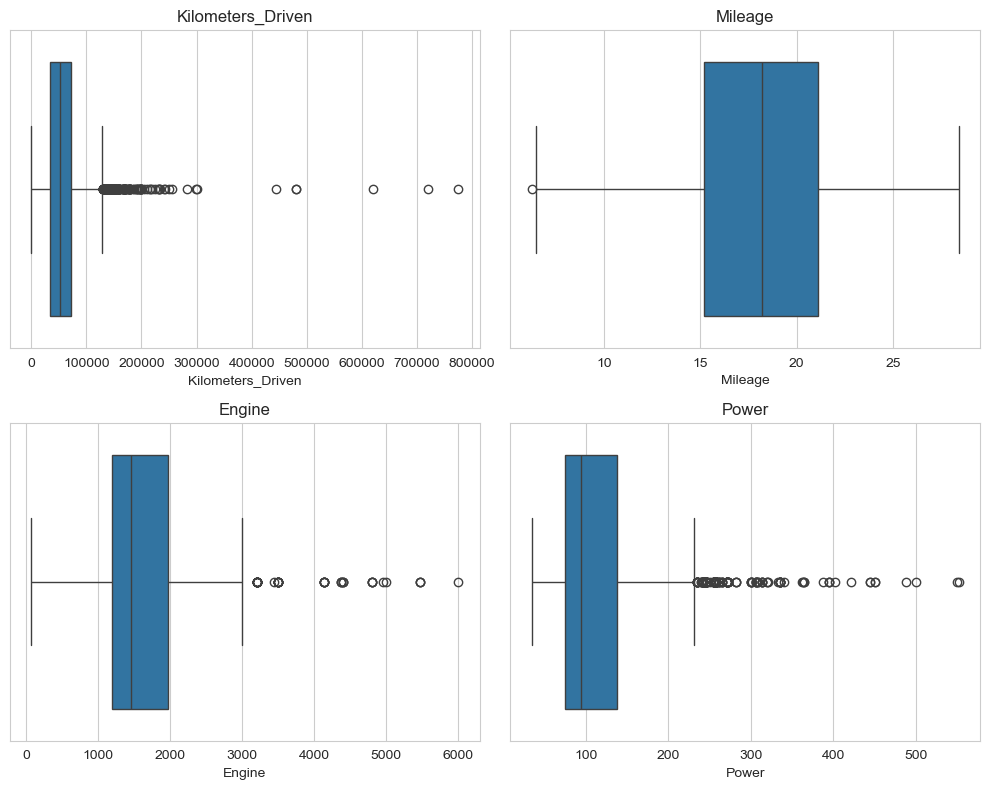

In [32]:
import math

# number of numeric features
n = len(num_features)

# choose grid size dynamically
rows = math.ceil(n / 2)  
cols = 2

plt.figure(figsize=(cols * 5, rows * 4))

for i, feature in enumerate(num_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=X_train[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

#### `Kilometers`, `Power` and `Engine` have outliers

## Detect Outliers using IQR

In [33]:
def detect_outliers_iqr(series, lower_percentile=25, upper_percentile=75, factor=1.5):
    Q1 = np.nanpercentile(series, lower_percentile)
    Q3 = np.nanpercentile(series, upper_percentile)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, len(outliers), lower, upper

`np.percentile()` ignores NaNs improperly — it can return NaN for Q1 or Q3, and as a result, lower and upper become NaN 

 so `(series < lower)` and `(series > upper)` are always False.

 → Use `np.nanpercentile()` instead of `np.percentile()` to safely handle NaNs.

In [34]:
for feature in num_features:
    outliers, count, _, _ = detect_outliers_iqr(X_train[feature])
    print(f'{feature} >> Outliers detected: {count}')


Kilometers_Driven >> Outliers detected: 171
Mileage >> Outliers detected: 1
Engine >> Outliers detected: 47
Power >> Outliers detected: 183


## Detect Outliers using Z-Score

In [35]:
def detect_outliers_zscore(series, threshold=3.0):
    mean = series.mean()
    std = series.std()
    real_threshold = threshold * std
    lower = mean - real_threshold
    upper = mean + real_threshold
    outliers = series[(series < lower) | (series > upper)]
    return outliers, len(outliers), lower, upper


In [36]:
for feature in num_features:
    outliers, count, _, _ = detect_outliers_zscore(X_train[feature])
    print(f'{feature} >> Outliers detected: {count}')


Kilometers_Driven >> Outliers detected: 49
Mileage >> Outliers detected: 0
Engine >> Outliers detected: 32
Power >> Outliers detected: 49


## Handle Outliers (Remove or Winsorize)

In [37]:
# Generalized function to handle outliers

def handle_outliers(series,  detect='iqr', method='winsorize'):
    if detect == 'iqr':
        _, _, lower, upper = detect_outliers_iqr(series)
    elif detect == 'zscore':
        _, _, lower, upper = detect_outliers_zscore(series)
    else:
        raise ValueError("detect must be 'iqr' or 'zscore'")

    if method == 'remove':
        return series[(series >= lower) & (series <= upper)]
    elif method == 'winsorize':
        return np.clip(series, lower, upper)
    else:
        raise ValueError("method must be 'remove' or 'winsorize'")


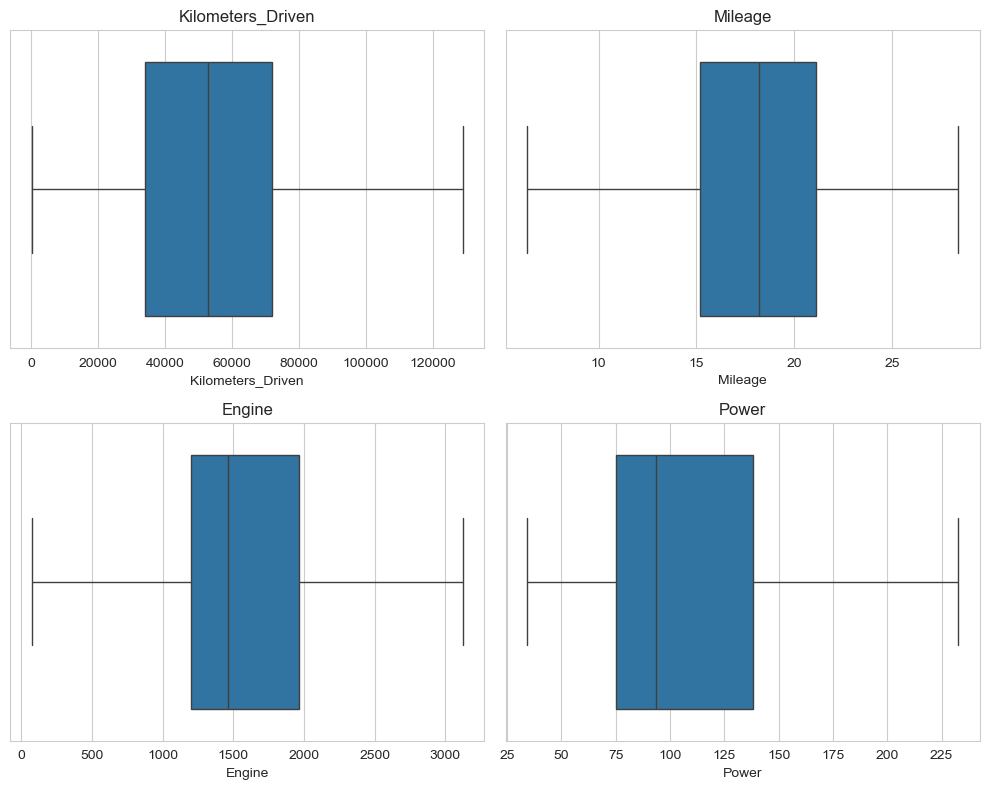

In [39]:
# Using IQR
X_train_handled = X_train.copy()

for feature in num_features:
    X_train_handled[feature] = handle_outliers(X_train[feature], detect='iqr', method='winsorize')

# number of numeric features
n = len(num_features)

# choose grid size dynamically
rows = math.ceil(n / 2)  
cols = 2

plt.figure(figsize=(cols * 5, rows * 4))

for i, feature in enumerate(num_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=X_train_handled[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [15]:
# Generalized function to handle outliers for both train and test sets

def handle_outliers(col,  detect='iqr', method='winsorize'):
    series_train = X_train[col].copy()
    series_test = X_test[col].copy()
    if detect == 'iqr':
        _, _, lower, upper = detect_outliers_iqr(series_train)
    elif detect == 'zscore':
        _, _, lower, upper = detect_outliers_zscore(series_train)
    else:
        raise ValueError("detect must be 'iqr' or 'zscore'")

    if method == 'remove':
        series_train = series_train[(series_train >= lower) & (series_train <= upper)]
        series_test = series_test[(series_test >= lower) & (series_test <= upper)]
        return series_train, series_test
    
    elif method == 'winsorize':
        series_train = np.clip(series_train, lower, upper)
        series_test = np.clip(series_test, lower, upper)
        return series_train, series_test
    else:
        raise ValueError("method must be 'remove' or 'winsorize'")


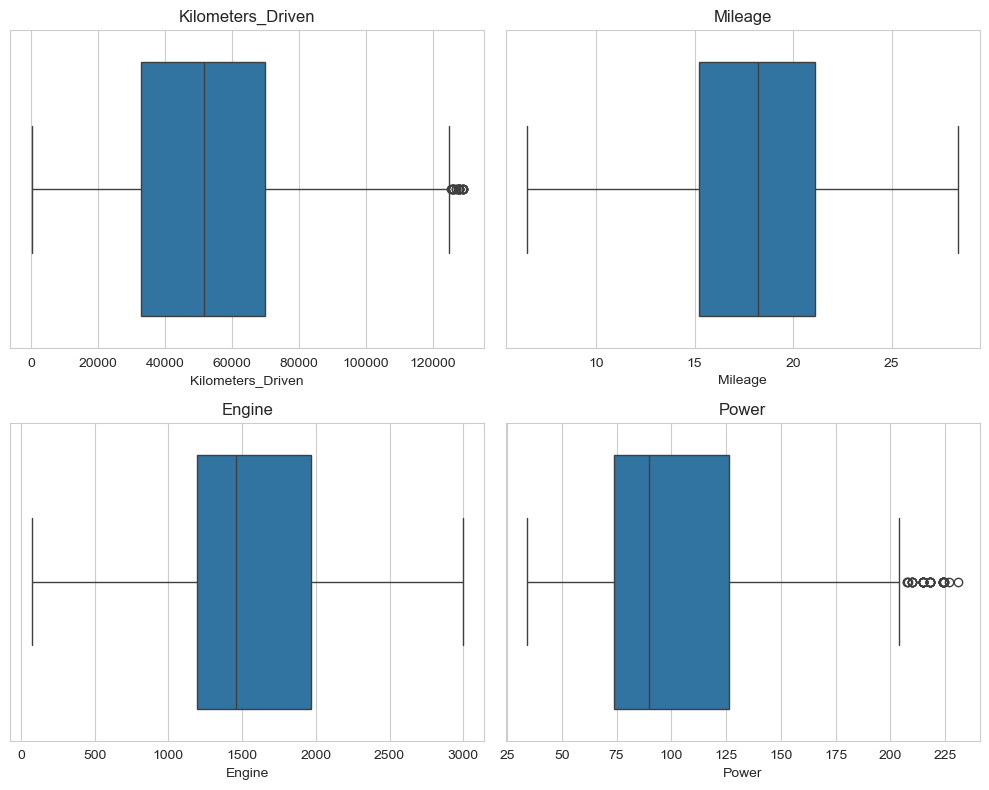

In [16]:
X_train_handled, X_test_handled = X_train.copy(), X_test.copy()

for feature in num_features:
    X_train_handled[feature], X_test_handled[feature] = handle_outliers(feature, detect='iqr', method='remove')

# number of numeric features
n = len(num_features)

# choose grid size dynamically
rows = math.ceil(n / 2)  
cols = 2

plt.figure(figsize=(cols * 5, rows * 4))

for i, feature in enumerate(num_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=X_train_handled[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [17]:
X_train_handled.shape, X_train.shape

((4812, 12), (4812, 12))

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, method='iqr', lower_percentile=25, upper_percentile=75,
                 iqr_factor=1.5, z_thresh=3.0, handle='winsorize'):
        self.method = method
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.iqr_factor = iqr_factor
        self.z_thresh = z_thresh
        self.handle = handle
        self.bounds_ = {}
        self.columns_ = None

    def fit(self, X, y=None):
        # Ensure input is a DataFrame
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        self.columns_ = X.select_dtypes(include=np.number).columns

        if self.method == 'iqr':
            Q1 = X[self.columns_].quantile(self.lower_percentile / 100.0)
            Q3 = X[self.columns_].quantile(self.upper_percentile / 100.0)
            IQR = Q3 - Q1
            lower = Q1 - self.iqr_factor * IQR
            upper = Q3 + self.iqr_factor * IQR
        elif self.method == 'zscore':
            mean = X[self.columns_].mean()
            std = X[self.columns_].std()
            lower = mean - self.z_thresh * std
            upper = mean + self.z_thresh * std
        else:
            raise ValueError("method must be 'iqr' or 'zscore'")

        self.bounds_ = {col: (lower[col], upper[col]) for col in self.columns_}
        return self

    def transform(self, X):
        # Convert to DataFrame (keep column names if possible)
        if isinstance(X, np.ndarray):
            if self.columns_ is not None and X.shape[1] == len(self.columns_):
                X = pd.DataFrame(X, columns=self.columns_)
            else:
                X = pd.DataFrame(X)

        X_copy = X.copy()

        # Apply outlier handling
        for col, (lower, upper) in self.bounds_.items():
            if self.handle == 'remove':
                X_copy[col] = X_copy[col].where((X_copy[col] >= lower) & (X_copy[col] <= upper))
            elif self.handle == 'winsorize':
                X_copy[col] = np.clip(X_copy[col], lower, upper)
            else:
                raise ValueError("handle must be 'remove' or 'winsorize'")
        
        return X_copy

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y).transform(X)

    def get_feature_names_out(self, input_features=None):
        # Return the same feature names
        if input_features is None and hasattr(self, "columns_"):
            return self.columns_
        return input_features


In [19]:
outlier_handler = OutlierHandler(method='iqr', handle='winsorize')
outlier_handler.fit(X_train)

OutlierHandler()

In [20]:
outlier_handler.bounds_

{'Year': (np.float64(2006.0), np.float64(2022.0)),
 'Kilometers_Driven': (np.float64(-23000.0), np.float64(129000.0)),
 'Mileage': (np.float64(6.349999999999996), np.float64(29.950000000000003)),
 'Engine': (np.float64(40.5), np.float64(3124.5)),
 'Power': (np.float64(-19.64999999999999), np.float64(232.75))}

In [21]:
X_train_handled = outlier_handler.fit_transform(X_train)  # fit and transform is defined in the class (TransformerMixin)
X_test_handled = outlier_handler.transform(X_test)

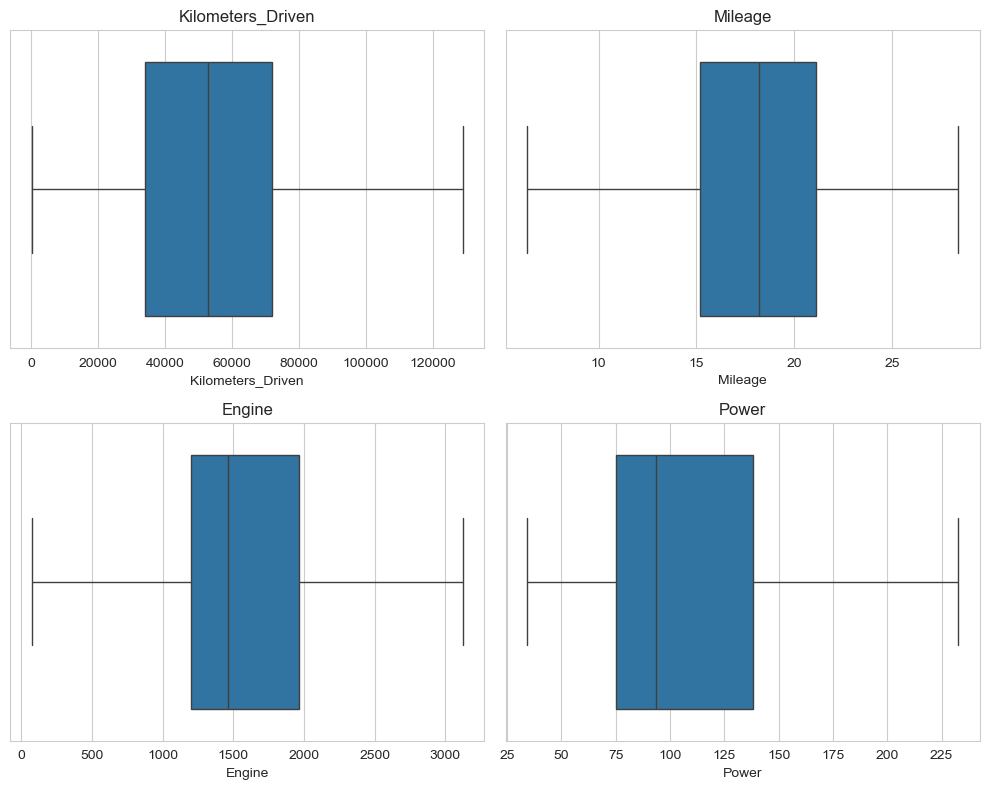

In [22]:
# number of numeric features
n = len(num_features)

# choose grid size dynamically
rows = math.ceil(n / 2)  
cols = 2

plt.figure(figsize=(cols * 5, rows * 4))

for i, feature in enumerate(num_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=X_train_handled[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [23]:
from scipy.stats.mstats import winsorize as sp_winsorize
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


# --- 1️⃣ Define function to apply winsorize column-wise ---
def winsorize_func(X, limits=(0.05, 0.05)):
    X = pd.DataFrame(X)  # ensure DataFrame
    X_wins = X.copy()
    for col in X_wins.columns:
        X_wins[col] = sp_winsorize(X_wins[col], limits=limits)
    return X_wins

# --- 2️⃣ Create FunctionTransformer ---
winsorizer = FunctionTransformer(func=winsorize_func, kw_args={'limits': (0.05, 0.05)}, validate=False)

# --- 3️⃣ Select columns ---
num_cols = X_train.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.to_list()

# --- 4️⃣ Build ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num_winsorize", winsorizer, num_cols),
        ("cat_passthrough", "passthrough", cat_cols)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

# --- 5️⃣ Fit / Transform ---
X_train_winsorized = preprocessor.fit_transform(X_train)
X_test_winsorized = preprocessor.transform(X_test)



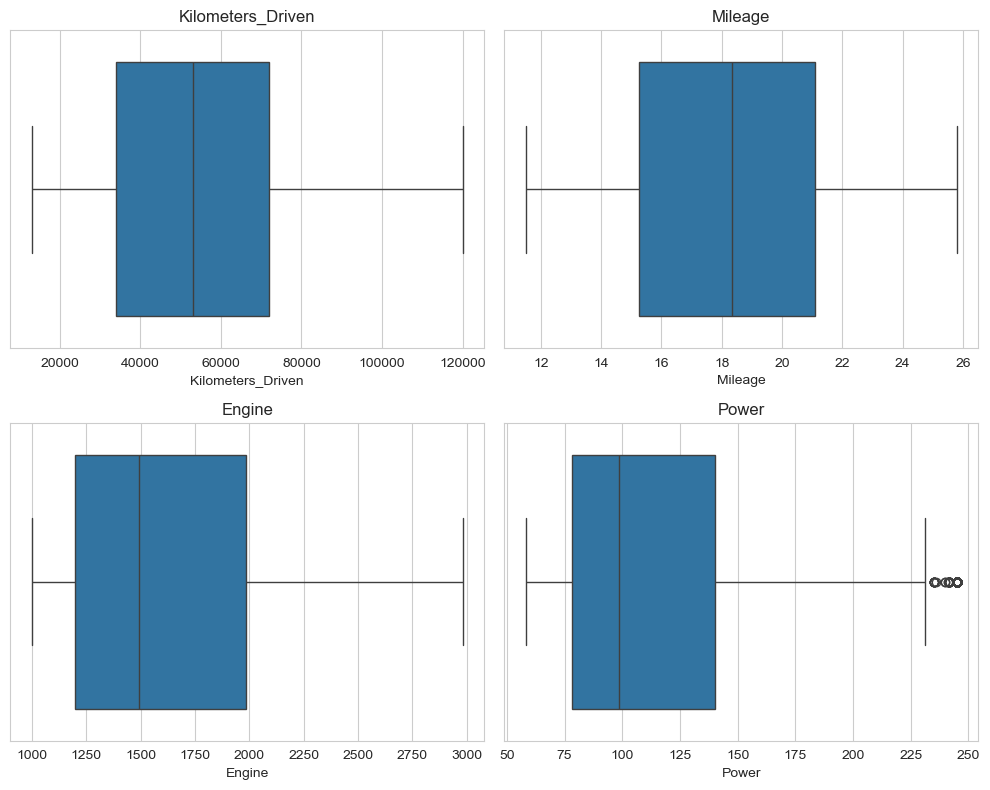

In [24]:
# number of numeric features
n = len(num_features)

# choose grid size dynamically
rows = math.ceil(n / 2)  
cols = 2

plt.figure(figsize=(cols * 5, rows * 4))

for i, feature in enumerate(num_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=X_train_winsorized[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()